### PPE Workplace Safety - Exploratory Data Analysis (EDA)

This notebook will help us understand the distribution of classes and visualize bounding boxes from our YOLO format dataset.

In [1]:
import os
import yaml
import glob
import cv2
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Set paths
DATA_DIR = '../data'
YAML_FILE = os.path.join(DATA_DIR, 'data.yaml')
TRAIN_IMAGES = os.path.join(DATA_DIR, 'train', 'images')
TRAIN_LABELS = os.path.join(DATA_DIR, 'train', 'labels')

In [2]:
# 1. Load class names from data.yaml
if not os.path.exists(YAML_FILE):
    print(f"Could not find {YAML_FILE}. Please make sure the dataset is extracted in the data folder.")
    classes = []
else:
    with open(YAML_FILE, 'r') as f:
        data_config = yaml.safe_load(f)

    names = data_config.get('names', [])
    if isinstance(names, dict):
        classes = [names[i] for i in range(len(names))]
    else:
        classes = names

    print("Classes found:", classes)
    print("Total classes:", len(classes))

Classes found: ['Gloves', 'Helmet', 'Human', 'Safety Boot', 'Safety Vest', 'boots', 'glasses', 'gloves', 'hat', 'helmet', 'no boot', 'no boots', 'no gloves', 'no hat', 'no vest', 'vest']
Total classes: 16


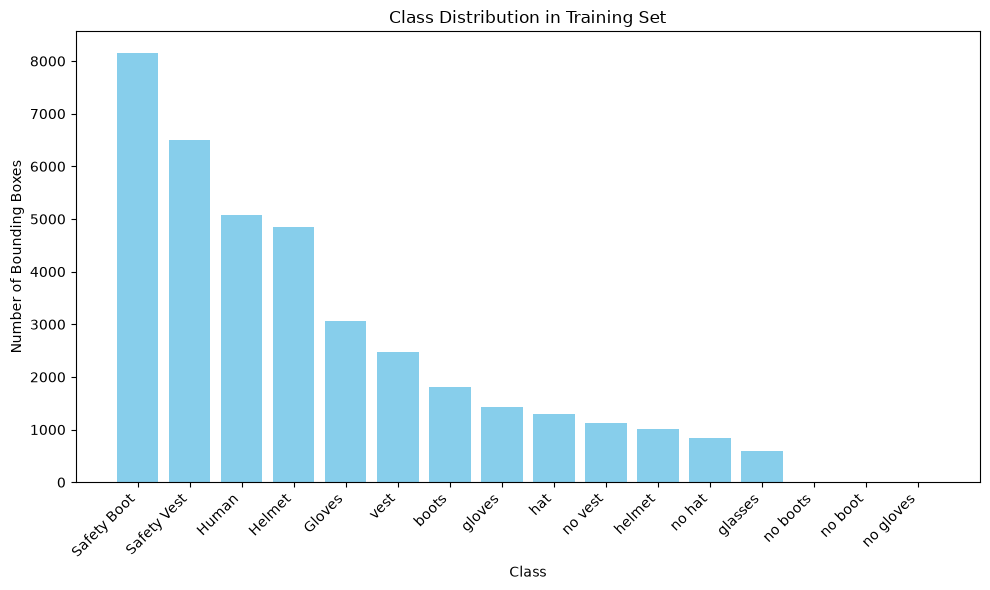

,Class,Count
3,Safety Boot,8157
4,Safety Vest,6506
2,Human,5078
1,Helmet,4843
0,Gloves,3057
15,vest,2481
5,boots,1811
7,gloves,1433
8,hat,1302
14,no vest,1135


In [3]:
# 2. Analyze Label Distribution
label_files = glob.glob(os.path.join(TRAIN_LABELS, '*.txt'))

if not label_files:
    print(f"No label files found in {TRAIN_LABELS}.")
elif len(classes) > 0:
    class_counts = {i: 0 for i in range(len(classes))}

    for label_file in label_files:
        with open(label_file, 'r') as f:
            lines = f.readlines()
            for line in lines:
                parts = line.split()
                if len(parts) > 0:
                    class_id = int(parts[0])
                    if class_id in class_counts:
                        class_counts[class_id] += 1

    df_counts = pd.DataFrame({
        'Class': classes,
        'Count': [class_counts[i] for i in range(len(classes))]
    }).sort_values('Count', ascending=False)

    plt.figure(figsize=(10, 6))
    plt.bar(df_counts['Class'], df_counts['Count'], color='skyblue')
    plt.xticks(rotation=45, ha='right')
    plt.title('Class Distribution in Training Set')
    plt.xlabel('Class')
    plt.ylabel('Number of Bounding Boxes')
    plt.tight_layout()
    plt.show()

    display(df_counts)
else:
    print("Cannot analyze distribution without class names.")

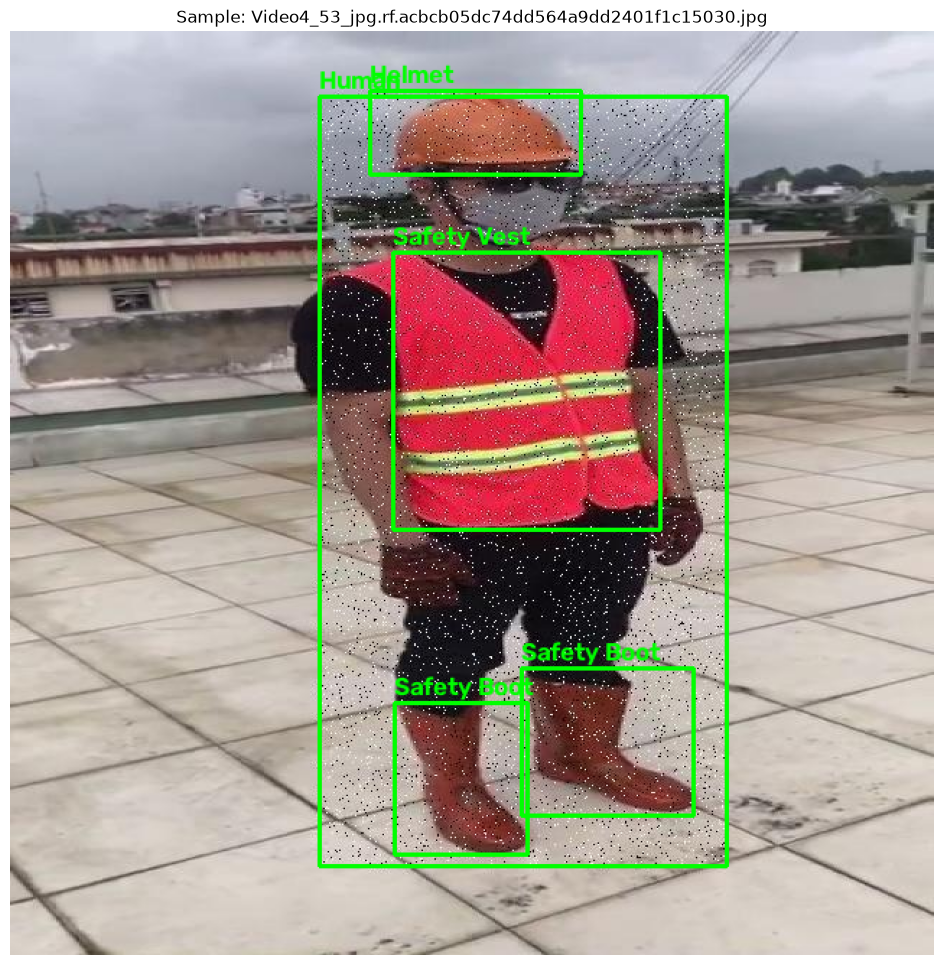

In [15]:
# 3. Visualize a Sample Image with Bounding Boxes
def plot_sample(image_file, label_file, classes):
    img = cv2.imread(image_file)
    if img is None:
        print(f"Could not read image: {image_file}")
        return
        
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    h, w, _ = img.shape
    
    with open(label_file, 'r') as f:
        lines = f.readlines()
    
    for line in lines:
        parts = line.strip().split()
        if len(parts) < 5: continue
        
        class_id = int(parts[0])
        x_center, y_center, bbox_w, bbox_h = map(float, parts[1:5])
        
        # Convert YOLO format (normalized) back to pixel coordinates
        x_min = int((x_center - bbox_w / 2) * w)
        y_min = int((y_center - bbox_h / 2) * h)
        x_max = int((x_center + bbox_w / 2) * w)
        y_max = int((y_center + bbox_h / 2) * h)
        
        # Draw rectangle and label
        color = (0, 255, 0) if 'NO' not in classes[class_id].upper() else (255, 0, 0)
        cv2.rectangle(img, (x_min, y_min), (x_max, y_max), color, 2)
        label = classes[class_id]
        cv2.putText(img, label, (x_min, max(y_min - 5, 10)), 
                    cv2.FONT_HERSHEY_SIMPLEX, 0.6, color, 2)
    
    plt.figure(figsize=(12, 12))
    plt.imshow(img)
    plt.axis('off')
    plt.title(f"Sample: {os.path.basename(image_file)}")
    plt.show()

# Try to show a random sample if data exists
if label_files and len(classes) > 0:
    import random
    sample_label = random.choice(label_files)
    # Note: Images might be .jpg, .jpeg, or .png. Let's try to find it.
    base_name = os.path.splitext(os.path.basename(sample_label))[0]
    img_path_pattern = os.path.join(TRAIN_IMAGES, f"{base_name}.*")
    matching_images = glob.glob(img_path_pattern)
    
    if matching_images:
        plot_sample(matching_images[0], sample_label, classes)
    else:
        print(f"Image not found for label {sample_label}")
else:
    print("Waiting for dataset to be downloaded...")